# Assignment 2 — Group 6
## Event Detection using Vision-Language Models

This notebook builds on `Demo_Event_Summarization_using_VLMs.ipynb`.
We reuse the same coding style and helper functions from the demo.

---

**Notebook roadmap**

| Step | Description | Status |
|------|-------------|--------|
| **Step 1** | Load videos and inspect metadata | ✅ |
| Step 2 | Sample frames from each video | ✅ |
| Step 3 | Run the VLM and detect events | ✅ |
| Step 4 | Parse, deduplicate, and evaluate results | ✅ |

## Imports

For this first step we only need **OpenCV** to read video metadata.
No model is loaded yet.

In [14]:
import cv2
import os

print("OpenCV version:", cv2.__version__)

OpenCV version: 4.13.0


## Video Paths

Edit the list below to point at your four video files.
Relative paths are resolved from the folder where this notebook lives.

In [15]:
# ── Set your video paths here ─────────────────────────────────────────────────
VIDEO_PATHS = [
    "video_21.mp4",
    "video_22.mp4",
    "video_23.mp4",
    "video_24.mp4",
]
# ─────────────────────────────────────────────────────────────────────────────

# Sanity-check: confirm every file exists before going further
for path in VIDEO_PATHS:
    status = "OK       " if os.path.isfile(path) else "NOT FOUND"
    print(f"  [{status}]  {path}")

  [OK       ]  video_21.mp4
  [OK       ]  video_22.mp4
  [OK       ]  video_23.mp4
  [OK       ]  video_24.mp4


## Helper Functions

Two small utilities, adapted from the demo notebook:

- **`format_duration(seconds)`** — converts a float (e.g. `125.4`) to `MM:SS` (e.g. `02:05`)
- **`get_video_info(path)`** — opens a video with OpenCV and returns its key metadata

In [16]:
def format_duration(seconds):
    """Convert seconds (float) to a MM:SS string."""
    total   = int(seconds)
    minutes = total // 60
    secs    = total % 60
    return f"{minutes:02d}:{secs:02d}"


def get_video_info(video_path):
    """Open a video with OpenCV and return its metadata as a dict."""
    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        raise RuntimeError(f"Cannot open video: {video_path}")

    fps          = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    duration_s   = total_frames / fps if fps > 0 else 0.0
    cap.release()

    return {
        "name":         os.path.splitext(os.path.basename(video_path))[0],
        "fps":          fps,
        "total_frames": total_frames,
        "duration_s":   duration_s,
        "duration_fmt": format_duration(duration_s),
    }

## Inspect Videos

Loop over every video and print its metadata:

| Field | Meaning |
|-------|---------|
| **Video name** | Filename without extension |
| **FPS** | Frames per second |
| **Total frames** | Total number of frames in the file |
| **Duration (s)** | Duration in decimal seconds |
| **Duration (MM:SS)** | Same duration in a human-readable format |

In [17]:
for path in VIDEO_PATHS:
    print("-" * 40)
    try:
        info = get_video_info(path)
        print(f"Video name      : {info['name']}")
        print(f"FPS             : {info['fps']:.2f}")
        print(f"Total frames    : {info['total_frames']}")
        print(f"Duration (s)    : {info['duration_s']:.2f}")
        print(f"Duration (MM:SS): {info['duration_fmt']}")
    except RuntimeError as e:
        print(f"ERROR: {e}")

print("-" * 40)

----------------------------------------
Video name      : video_21
FPS             : 29.97
Total frames    : 19406
Duration (s)    : 647.51
Duration (MM:SS): 10:47
----------------------------------------
Video name      : video_22
FPS             : 24.00
Total frames    : 5661
Duration (s)    : 235.88
Duration (MM:SS): 03:55
----------------------------------------
Video name      : video_23
FPS             : 29.97
Total frames    : 5631
Duration (s)    : 187.89
Duration (MM:SS): 03:07
----------------------------------------
Video name      : video_24
FPS             : 29.97
Total frames    : 4356
Duration (s)    : 145.35
Duration (MM:SS): 02:25
----------------------------------------


---

## Step 2 — Frame Sampling

Before running the VLM we extract representative frames from each video.

**Strategy:** sample one frame every `SAMPLE_INTERVAL` seconds (uniform temporal sampling).  
This is the same approach used in `sample_frames_sparse` in the demo notebook — read through the video and grab a frame whenever enough time has passed since the last sample.

Each sampled frame is stored as a dict so we always know exactly where it came from:

```python
{
    "video_name":    "video_21",
    "frame_index":   150,       # position in the file
    "timestamp_s":   5.0,       # seconds from the start
    "timestamp_fmt": "00:05",   # MM:SS
    "image":         <PIL Image>
}
```

Frames are kept in **chronological order** (earliest → latest).

In [18]:
from PIL import Image

# ── Tune this to get coarser or finer coverage ────────────────────────────────
SAMPLE_INTERVAL = 2   # seconds between sampled frames
# ─────────────────────────────────────────────────────────────────────────────


def sample_frames(video_path, interval_seconds=2):
    """
    Sample one frame every `interval_seconds` from a video.

    Adapted from `sample_frames_sparse` in the demo notebook.

    Returns a list of dicts sorted by frame_index (chronological order):
        video_name    – filename without extension
        frame_index   – absolute frame number in the video file
        timestamp_s   – time in seconds (float)
        timestamp_fmt – time as MM:SS string
        image         – PIL Image (RGB)
    """
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise RuntimeError(f"Cannot open video: {video_path}")

    fps        = cap.get(cv2.CAP_PROP_FPS)
    video_name = os.path.splitext(os.path.basename(video_path))[0]

    if fps <= 0:
        cap.release()
        raise RuntimeError(f"Could not read FPS for: {video_path}")

    frames       = []
    frame_index  = 0
    next_capture = 0.0   # next timestamp we want to capture

    while True:
        ok, bgr = cap.read()
        if not ok:
            break

        timestamp_s = frame_index / fps

        if timestamp_s >= next_capture - 1e-6:   # small epsilon for float safety
            rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
            frames.append({
                "video_name":    video_name,
                "frame_index":   frame_index,
                "timestamp_s":   round(timestamp_s, 3),
                "timestamp_fmt": format_duration(timestamp_s),
                "image":         Image.fromarray(rgb),
            })
            next_capture += interval_seconds

        frame_index += 1

    cap.release()

    # Already in order, but sort explicitly to be safe
    frames.sort(key=lambda f: f["frame_index"])
    return frames

### Run sampling on all videos

Results go into `all_frames` — a dict keyed by video name.  
A summary line is printed for each video so we can verify the sampling worked.

In [19]:
all_frames = {}   # { video_name: [ frame_dict, ... ] }

for path in VIDEO_PATHS:
    print(f"Sampling  {path} ...", end="  ")
    try:
        frames     = sample_frames(path, interval_seconds=SAMPLE_INTERVAL)
        video_name = frames[0]["video_name"]
        all_frames[video_name] = frames

        first_ts = frames[0]["timestamp_fmt"]
        last_ts  = frames[-1]["timestamp_fmt"]
        print(f"{len(frames)} frames  ({first_ts} → {last_ts})")
    except RuntimeError as e:
        print(f"ERROR: {e}")

print("\nSampling complete.")

Sampling  video_21.mp4 ...  324 frames  (00:00 → 10:46)
Sampling  video_22.mp4 ...  118 frames  (00:00 → 03:54)
Sampling  video_23.mp4 ...  94 frames  (00:00 → 03:06)
Sampling  video_24.mp4 ...  73 frames  (00:00 → 02:24)

Sampling complete.


### Preview sampled frames

6 evenly-spaced thumbnails per video, each labelled with its `MM:SS` timestamp,
so we can visually confirm the sampling covers the full timeline.

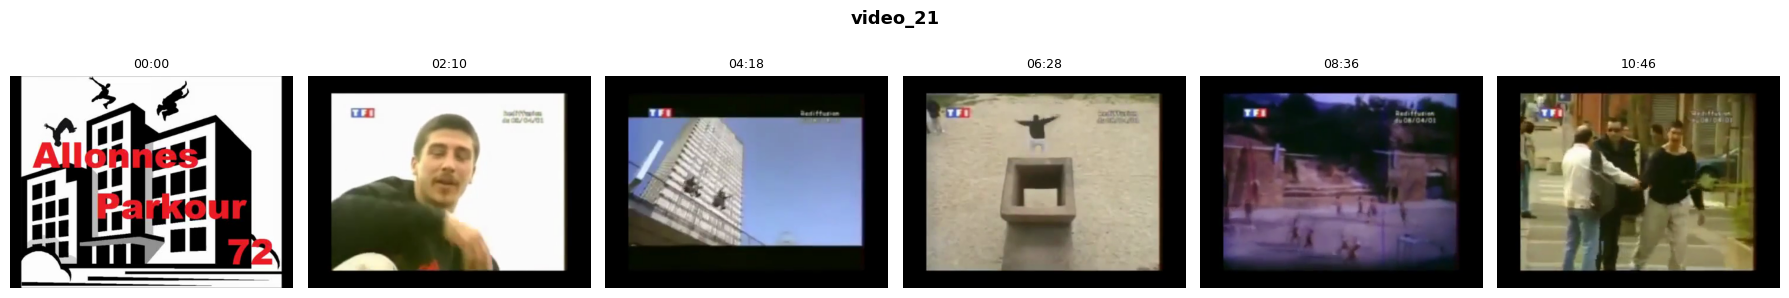

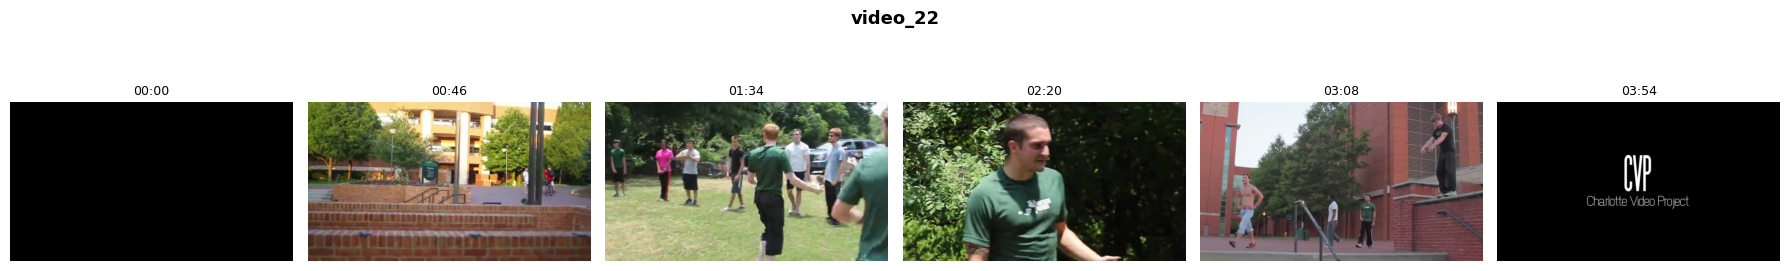

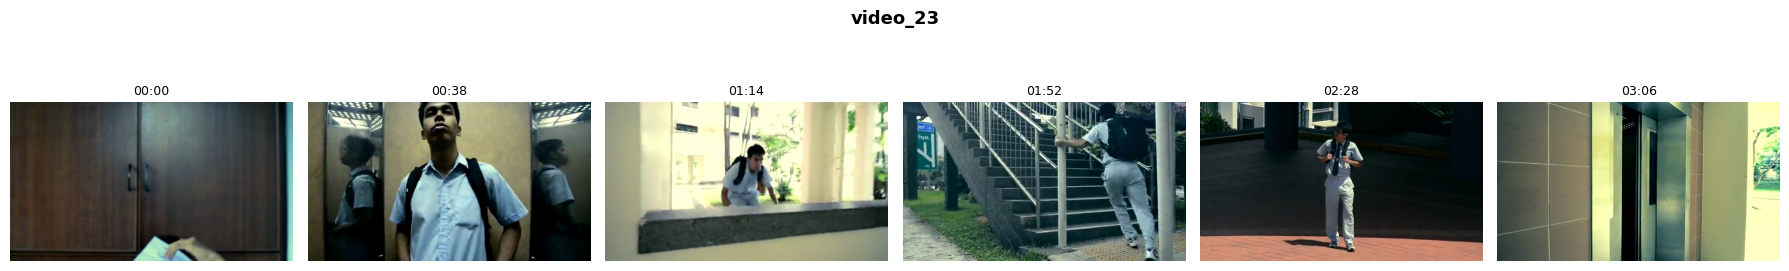

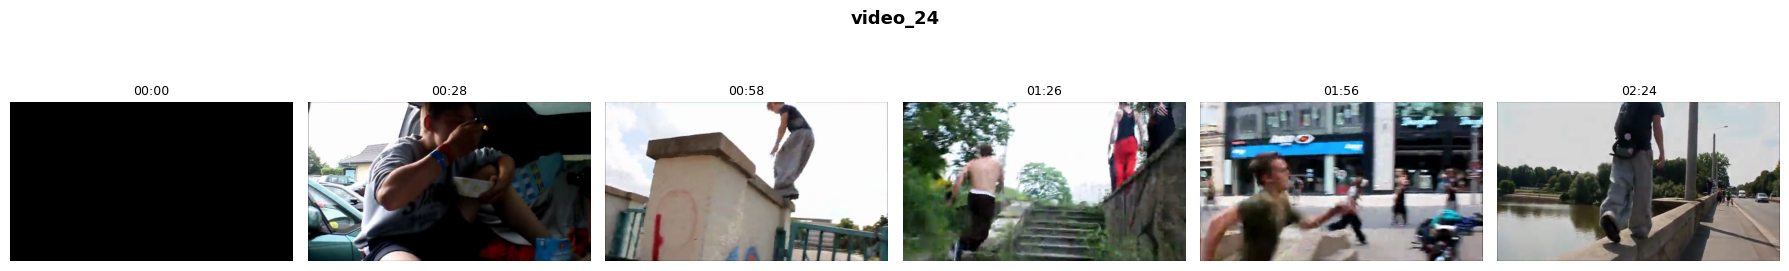

In [20]:
import matplotlib.pyplot as plt

PREVIEW_COUNT = 6   # thumbnails to show per video


def pick_preview_frames(frames, n=PREVIEW_COUNT):
    """Return n evenly-spaced frames from the full list."""
    if len(frames) <= n:
        return frames
    step = (len(frames) - 1) / (n - 1)
    return [frames[round(i * step)] for i in range(n)]


for video_name, frames in all_frames.items():
    preview = pick_preview_frames(frames, PREVIEW_COUNT)

    fig, axes = plt.subplots(1, len(preview), figsize=(3 * len(preview), 3))
    fig.suptitle(video_name, fontsize=13, fontweight="bold", y=1.02)

    for ax, f in zip(axes, preview):
        ax.imshow(f["image"])
        ax.set_title(f["timestamp_fmt"], fontsize=9)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

---

## Step 3 — Load the Vision-Language Model

We use the same model as the demo notebook: **SmolVLM2-2.2B-Instruct**.

It is a lightweight, open-source vision-language model hosted on HuggingFace.
At ~2B parameters it can run on a laptop GPU (or even CPU, slowly).

The loading pattern is identical to the demo:
- `AutoProcessor` handles both the text tokenizer and image pre-processing
- `AutoModelForImageTextToText` is the unified class for image-text models in `transformers`
- `device_map="auto"` lets HuggingFace decide how to distribute layers across available hardware

In [21]:
import torch
from transformers import AutoProcessor, AutoModelForImageTextToText

# ── Model selection (same as the demo notebook) ───────────────────────────────
MODEL_NAME = "HuggingFaceTB/SmolVLM2-2.2B-Instruct"
# ─────────────────────────────────────────────────────────────────────────────

# Detect the best available device
gpu_available = torch.cuda.is_available()
if gpu_available:
    device = "cuda"
elif torch.backends.mps.is_available():   # Apple Silicon
    device = "mps"
else:
    device = "cpu"

print(f"Model      : {MODEL_NAME}")
print(f"GPU available : {gpu_available}")
print(f"Device     : {device}")

Model      : HuggingFaceTB/SmolVLM2-2.2B-Instruct
GPU available : False
Device     : mps


### Load processor and model

The cell below downloads the model weights the first time it runs (~4 GB).
Subsequent runs load from the local HuggingFace cache and are much faster.

> **Note:** `device_map="auto"` is used exactly as in the demo — it automatically
> offloads layers to disk if VRAM is tight, so the model loads even on machines
> with limited GPU memory.

In [22]:
# If you already ran this cell, restart the kernel first to fully free the old model
# from MPS memory before reloading in float16.

processor = AutoProcessor.from_pretrained(MODEL_NAME)
processor.image_processor.do_image_splitting = False  # prevents 9x tile explosion that causes OOM on MPS

model = AutoModelForImageTextToText.from_pretrained(
    MODEL_NAME,
    device_map="auto",
    torch_dtype=torch.float16,   # halves VRAM: ~4.4 GB instead of ~17 GB in float32
    trust_remote_code=True,
)

print(f"Processor    : {type(processor).__name__}")
print(f"Model        : {type(model).__name__}")
print(f"Model dtype  : {next(model.parameters()).dtype}")
print(f"Model device : {next(model.parameters()).device}")
print("\nModel loaded and ready.")

Loading checkpoint shards: 100%|██████████| 2/2 [00:23<00:00, 11.59s/it]


Processor    : SmolVLMProcessor
Model        : SmolVLMForConditionalGeneration
Model dtype  : torch.float16
Model device : mps:0

Model loaded and ready.


---

## Step 4 — Target Event Count per Video

VLMs tend to be verbose: if we don't constrain the output, they produce too many
redundant events for short clips or too few for long ones.

The fix is to tell the model **how many events to aim for** as part of the prompt.
The target range is based purely on video duration — the longer the video,
the more events we expect.

| Duration | Target events |
|----------|---------------|
| 1–2 min  | 4–6           |
| 3–5 min  | 6–10          |
| 6–10 min | 10–15         |
| > 10 min | 12–18         |

`get_target_event_range(duration_seconds)` encodes this logic and also returns a
short prompt snippet ready to be embedded in the VLM instruction.

In [23]:
def get_target_event_range(duration_seconds):
    """
    Return the target event count range for a given video duration.

    Args:
        duration_seconds: float — total video length in seconds

    Returns:
        min_events   : int   — lower bound of expected salient events
        max_events   : int   — upper bound of expected salient events
        prompt_hint  : str   — ready-to-use sentence for the VLM prompt
    """
    minutes = duration_seconds / 60.0

    if minutes <= 2:
        min_events, max_events = 4, 6
    elif minutes <= 5:
        min_events, max_events = 6, 10
    elif minutes <= 10:
        min_events, max_events = 10, 15
    else:
        min_events, max_events = 12, 18

    prompt_hint = (
        f"Identify between {min_events} and {max_events} distinct salient events."
    )

    return min_events, max_events, prompt_hint

### Apply to all 4 videos

We reuse the `get_video_info` function from Step 1 to get each video's duration,
then pass it to `get_target_event_range`.

In [24]:
print(f"{'Video':<12}  {'Duration':>10}  {'Min':>5}  {'Max':>5}  Prompt hint")
print("-" * 75)

for path in VIDEO_PATHS:
    info = get_video_info(path)
    min_ev, max_ev, hint = get_target_event_range(info["duration_s"])

    print(
        f"{info['name']:<12}  "
        f"{info['duration_fmt']:>6} ({info['duration_s']:>6.1f}s)  "
        f"{min_ev:>5}  "
        f"{max_ev:>5}  "
        f"{hint}"
    )

Video           Duration    Min    Max  Prompt hint
---------------------------------------------------------------------------
video_21       10:47 ( 647.5s)     12     18  Identify between 12 and 18 distinct salient events.
video_22       03:55 ( 235.9s)      6     10  Identify between 6 and 10 distinct salient events.
video_23       03:07 ( 187.9s)      6     10  Identify between 6 and 10 distinct salient events.
video_24       02:25 ( 145.3s)      6     10  Identify between 6 and 10 distinct salient events.


---

## Step 5 — Event-Only Detection

We now send the sampled frames to SmolVLM2 and ask it to return a numbered list
of salient events — no timestamps yet.

**Frame passing strategy** (same as demo notebook cell 14):
- Frames are passed as PIL Images inside the `content` list via `{"type": "image", "url": pil_image}`
- The processor's `apply_chat_template` handles resizing and tokenisation
- We cap at **16 frames per call** to stay within memory limits (the demo uses 15)
  — if we sampled more than that, we pick 16 evenly-spaced ones

**Prompt strategy:**
- The prompt is injected after all frame entries (images first, text last)
- `[MIN]` and `[MAX]` are filled in from `get_target_event_range` so the model
  knows how many events to aim for
- A strict output format (`Salient event N: ...`) is enforced to make parsing easy later

In [ ]:
import gc
import os
import tempfile

MAX_FRAMES_PER_CALL = 6


def _subsample_frames(frames, n=MAX_FRAMES_PER_CALL):
    if len(frames) <= n:
        return frames
    step = (len(frames) - 1) / (n - 1)
    return [frames[round(i * step)] for i in range(n)]


def _free_mps_cache():
    gc.collect()
    if torch.backends.mps.is_available():
        torch.mps.synchronize()
        torch.mps.empty_cache()


def _build_prompt(min_events, max_events):
    return (
        "Analyze the sampled frames from this video in chronological order.\n"
        "Retrieve the salient events of the video.\n"
        "Do not describe every frame.\n"
        "Group repeated or similar actions into one event.\n"
        "Focus on meaningful actions, scene changes, or important transitions.\n"
        f"Return between {min_events} and {max_events} salient events.\n"
        "The events must be in chronological order.\n"
        "\n"
        "Number each event starting from 1, one per line:\n"
        "1. <description>\n"
        "2. <description>\n"
        "3. <description>"
        "\n"
        "Do not include extra explanation."
    )


def run_vlm_event_only(video_path, sampled_frames, min_events, max_events):
    _free_mps_cache()

    frames_to_use = _subsample_frames(sampled_frames, MAX_FRAMES_PER_CALL)
    prompt        = _build_prompt(min_events, max_events)

    # Save frames to temp JPEG files and pass file paths — same approach as
    # the demo notebook (cell 10). Passing PIL objects as "url" causes the
    # processor to produce all-zero pixel_values, so the model sees nothing.
    tmp_paths = []
    content   = []
    for f in frames_to_use:
        fd, path = tempfile.mkstemp(suffix=".jpg")
        os.close(fd)
        f["image"].save(path, format="JPEG", quality=90)
        tmp_paths.append(path)
        content.append({"type": "image", "url": path})
    content.append({"type": "text", "text": prompt})

    messages = [{"role": "user", "content": content}]

    inputs = processor.apply_chat_template(
        messages,
        add_generation_prompt=True,
        tokenize=True,
        return_dict=True,
        return_tensors="pt",
    ).to(model.device)

    input_len = inputs["input_ids"].shape[1]

    with torch.no_grad():
        generated_ids = model.generate(
            **inputs,
            do_sample=False,
            max_new_tokens=250,
            min_new_tokens=60,
            repetition_penalty=1.3,
        )

    # Decode only the newly generated tokens — no fragile "Assistant:" split needed
    new_tokens = generated_ids[:, input_len:]
    raw = processor.batch_decode(new_tokens, skip_special_tokens=True)[0].strip()

    for p in tmp_paths:
        os.unlink(p)

    del inputs, generated_ids, new_tokens
    _free_mps_cache()

    return raw, prompt


### Run inference — one video at a time

MPS (Apple Silicon GPU) does not fully release memory between inference calls in the same
kernel session. Running all 4 videos in a single loop causes the allocator to accumulate
~15 GB of stale tensors by the third video, which triggers an OOM.

**Workflow — do this for each video:**
1. Set `VIDEO_INDEX` to `0`, `1`, `2`, or `3`
2. Run the cell
3. **Restart the kernel** (`Kernel → Restart`)
4. Re-run all cells from the top down to this point
5. Repeat with the next index

Results are printed immediately below the cell.
After all 4 runs, `event_only_results` will contain every video's output.

In [26]:
# -- Pick which video to process (0 = video_21, 1 = video_22, 2 = video_23, 3 = video_24) --
VIDEO_INDEX = 0
# ------------------------------------------------------------------------------------------

import json
import re

# Determine video name early so RESULTS_PATH can include it
_vpath      = VIDEO_PATHS[VIDEO_INDEX]
_vinfo      = get_video_info(_vpath)
_video_name = _vinfo["name"]

RESULTS_PATH               = os.path.join("outputs", f"event_only_results_{_video_name}.json")
RETRY_MAX_FRAMES           = 3
RETRY_IMAGE_SIZE           = (288, 288)
ROBUST_MIN_NEW_TOKENS      = 12
GENERATION_MAX_NEW_TOKENS  = 160
GENERATION_MAX_TIME_SECONDS = 180


def _load_event_results(path=RESULTS_PATH):
    if not os.path.isfile(path):
        return {}
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def _save_event_results(results, path=RESULTS_PATH):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(results, f, indent=2)


def _first_real_model_device_and_dtype():
    for parameter in model.parameters():
        if parameter.device.type != "meta":
            return parameter.device, parameter.dtype
    return model.device, torch.float16


def _move_inputs_to_model(inputs):
    device, dtype = _first_real_model_device_and_dtype()
    moved = {}
    for key, value in inputs.items():
        if value.is_floating_point():
            moved[key] = value.to(device=device, dtype=dtype)
        else:
            moved[key] = value.to(device=device)
    return moved


def _extract_assistant_answer(text):
    """Strip chat-template leftovers and keep only the assistant answer."""
    if not text:
        return ""
    text = text.replace("<end_of_utterance>", "").strip()
    for marker in ("Assistant:", "assistant:"):
        if marker in text:
            text = text.rsplit(marker, 1)[-1].strip()
    text = re.sub(r"^User:.*?(?=\n?\d+[\).]\s)", "", text, flags=re.DOTALL).strip()
    return text


def _decode_new_answer(generated_ids, input_len):
    new_tokens = generated_ids[:, input_len:]
    new_text = processor.batch_decode(new_tokens, skip_special_tokens=True)[0]
    full_text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
    answer = _extract_assistant_answer(new_text)
    if not answer:
        answer = _extract_assistant_answer(full_text)
    return answer.strip(), full_text


def _build_timestamped_retry_content(video_name, info, sampled_frames, min_events, max_events):
    frames_to_use = _subsample_frames(sampled_frames, RETRY_MAX_FRAMES)
    frame_times = [f["timestamp_fmt"] for f in frames_to_use]

    prompt = (
        f"You are analyzing sampled frames from {video_name}.\n"
        f"Video duration: {info['duration_fmt']} ({info['duration_s']:.1f} seconds).\n"
        "The frames below are in chronological order and each label gives its approximate timestamp.\n"
        "Identify the main visible actions, scene changes, or important transitions.\n"
        "Merge repeated/similar actions into one event.\n"
        f"Return {min_events} to {max_events} events if possible, but do not return an empty answer.\n\n"
        "Use exactly this numbered format:\n"
        "1. Event description\n"
        "2. Event description\n"
        "3. Event description"
    )

    content = [{"type": "text", "text": prompt}]
    for i, frame in enumerate(frames_to_use, start=1):
        content.append({
            "type": "text",
            "text": f"Frame {i} at approximately {frame['timestamp_fmt']}:",
        })
        content.append({"type": "image", "url": _resize(frame["image"], RETRY_IMAGE_SIZE)})

    return content, prompt, frame_times


def _generate_from_content(content, *, min_new_tokens=0, do_sample=False):
    _free_mps_cache()

    messages = [{"role": "user", "content": content}]
    inputs = processor.apply_chat_template(
        messages,
        add_generation_prompt=True,
        tokenize=True,
        return_dict=True,
        return_tensors="pt",
    )
    inputs = _move_inputs_to_model(inputs)
    input_len = inputs["input_ids"].shape[1]

    generation_kwargs = {
        "do_sample": do_sample,
        "max_new_tokens": GENERATION_MAX_NEW_TOKENS,
        "max_time": GENERATION_MAX_TIME_SECONDS,
        "min_new_tokens": min_new_tokens,
        "pad_token_id": processor.tokenizer.eos_token_id,
    }
    if do_sample:
        generation_kwargs.update({"temperature": 0.35, "top_p": 0.9})

    with torch.no_grad():
        generated_ids = model.generate(**inputs, **generation_kwargs)

    answer, full_text = _decode_new_answer(generated_ids, input_len)

    del inputs, generated_ids
    _free_mps_cache()

    return answer, full_text


def run_vlm_event_only_with_retry(video_path, sampled_frames, min_events, max_events, info):
    attempts = []

    raw, prompt = run_vlm_event_only(video_path, sampled_frames, min_events, max_events)
    attempts.append({
        "name": "original_prompt",
        "empty": not bool(raw.strip()),
        "prompt": prompt,
    })
    if raw.strip():
        return raw.strip(), prompt, attempts

    content, retry_prompt, frame_times = _build_timestamped_retry_content(
        info["name"], info, sampled_frames, min_events, max_events
    )
    print(
        f"Original attempt returned empty output; retrying with {RETRY_MAX_FRAMES} "
        f"timestamp-labeled frames at {RETRY_IMAGE_SIZE[0]}x{RETRY_IMAGE_SIZE[1]} ...",
        flush=True,
    )
    raw, full_text = _generate_from_content(
        content,
        min_new_tokens=ROBUST_MIN_NEW_TOKENS,
        do_sample=False,
    )
    attempts.append({
        "name": "timestamped_retry_greedy",
        "empty": not bool(raw.strip()),
        "frame_times": frame_times,
        "prompt": retry_prompt,
        "full_decode_tail": full_text[-600:],
    })
    if raw.strip():
        return raw.strip(), retry_prompt, attempts

    print("Greedy retry was still empty; trying one low-temperature sampled retry ...", flush=True)
    raw, full_text = _generate_from_content(
        content,
        min_new_tokens=ROBUST_MIN_NEW_TOKENS,
        do_sample=True,
    )
    attempts.append({
        "name": "timestamped_retry_sampled",
        "empty": not bool(raw.strip()),
        "frame_times": frame_times,
        "prompt": retry_prompt,
        "full_decode_tail": full_text[-600:],
    })
    if raw.strip():
        return raw.strip(), retry_prompt, attempts

    raise RuntimeError(
        "SmolVLM returned an empty answer after 3 attempts. "
        "Check event_only_results for the decoded tails, or reduce MAX_FRAMES_PER_CALL and restart the kernel."
    )


if "event_only_results" not in globals():
    event_only_results = {}
event_only_results.update(_load_event_results())

path       = _vpath
info       = _vinfo
video_name = _video_name
frames     = all_frames[video_name]
min_ev, max_ev, _ = get_target_event_range(info["duration_s"])

print(f"{'—' * 60}")
print(f"Video        : {video_name}")
print(f"Duration     : {info['duration_fmt']}  ({info['duration_s']:.1f}s)")
print(f"Frames used  : {min(len(frames), MAX_FRAMES_PER_CALL)} / {len(frames)} sampled")
print(f"Target events: {min_ev} - {max_ev}")
print(f"{'—' * 60}")
print("Running VLM ...", flush=True)

# For long videos split into temporal segments so each call only sees
# MAX_FRAMES_PER_CALL frames (avoids OOM) while covering the full timeline.
N_SEGMENTS = 3 if info["duration_s"] > 300 else 1

if N_SEGMENTS == 1:
    raw, prompt, attempts = run_vlm_event_only_with_retry(path, frames, min_ev, max_ev, info)
else:
    seg_size  = len(frames) // N_SEGMENTS
    seg_min   = max(2, min_ev  // N_SEGMENTS)
    seg_max   = max(4, max_ev  // N_SEGMENTS + 2)
    all_raws, all_prompts, all_attempts = [], [], []

    for i in range(N_SEGMENTS):
        start      = i * seg_size
        end        = (i + 1) * seg_size if i < N_SEGMENTS - 1 else len(frames)
        seg_frames = frames[start:end]
        print(
            f"  Segment {i+1}/{N_SEGMENTS}  "
            f"({seg_frames[0]['timestamp_fmt']} → {seg_frames[-1]['timestamp_fmt']}) ...",
            flush=True,
        )
        seg_raw, seg_prompt, seg_attempts = run_vlm_event_only_with_retry(
            path, seg_frames, seg_min, seg_max, info
        )
        if seg_raw.strip():
            all_raws.append(seg_raw.strip())
        all_prompts.append(seg_prompt)
        all_attempts.extend(seg_attempts)

    # Strip any "Salient event N:" / "N." prefixes and renumber from 1
    import re as _re
    clean_events = []
    for chunk in all_raws:
        for line in chunk.split("\n"):
            line = line.strip()
            if not line:
                continue
            line = _re.sub(r"^[Ss]al[ei]e?nt\s+event\s+\d+\s*:\s*", "", line)
            line = _re.sub(r"^\d+[\.)\-]\s*", "", line).strip()
            if line:
                clean_events.append(line)
    raw      = "\n".join(f"{i+1}. {e}" for i, e in enumerate(clean_events))
    prompt   = all_prompts[0]
    attempts = all_attempts

event_only_results[video_name] = {
    "raw": raw,
    "prompt": prompt,
    "attempts": attempts,
}
_save_event_results(event_only_results)

print("\nDetected events:")
print("-" * 40)
print(raw)
print("-" * 40)
print(f"\nDone. Results saved to event_only_results['{video_name}']")
print(f"Also written to: {RESULTS_PATH}")
print(f"Attempts used: {[attempt['name'] for attempt in attempts]}")
print(f"Videos processed so far: {list(event_only_results.keys())}")
print("\nNext step: restart kernel, re-run all cells, then change VIDEO_INDEX.")

————————————————————————————————————————————————————————————
Video        : video_21
Duration     : 10:47  (647.5s)
Frames used  : 6 / 324 sampled
Target events: 12 - 18
————————————————————————————————————————————————————————————
Running VLM ...
  Segment 1/3  (00:00 → 03:34) ...
  Segment 2/3  (03:36 → 07:10) ...
  Segment 3/3  (07:12 → 10:46) ...

Detected events:
----------------------------------------
1. A man is running down a street with buildings behind him.
2. The same person continues to run past some trees before turning around.
3. He then runs towards an open field where he stops near tall grass.
4. Another angle shows someone standing by cars parked along the side of the road.
5. An aerial view reveals more details about nearby houses and fields.
6. Finally, another close-up shot focuses on people walking through what appears to be a park area.
7. A man is walking down a hallway with another person following him.
8. The camera pans to show an empty room where people are s

---
**Next:** Step 6 — parse the raw VLM output into a structured list of events.